In [2]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [3]:
!git clone https://github.com/monicaccmartins/MIQR-CC-Dataset.git
!pip install monai livelossplot torchmetrics seaborn

fatal: destination path 'MIQR-CC-Dataset' already exists and is not an empty directory.


⚡️ Tip	Connect GitHub to Studios: https://lightning.ai/pg60017/home?settings=integrations



In [4]:
from livelossplot import PlotLosses 
from livelossplot.outputs import MatplotlibPlot
%matplotlib inline
import matplotlib.pyplot as plt
from monai.transforms import (Activations, AsDiscrete, LoadImage, EnsureChannelFirst, Resize,
                                RandZoom, RandAdjustContrast, RandGaussianNoise, RandRotate,
                                RandFlip, ToTensor, Compose, NormalizeIntensity, Lambda)
from monai.data import decollate_batch, DataLoader
from monai.metrics import ROCAUCMetric
from monai.utils import set_determinism
from monai.config import print_config
import numpy as np
import os
from PIL import Image
import random
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score
import time
import torch
from torch.utils.data import Dataset, WeightedRandomSampler
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights
import torch.nn as nn
from torchmetrics.classification import MulticlassF1Score

np.random.seed(0)
set_determinism(seed=0)
print_config()

MONAI version: 1.5.2
Numpy version: 1.26.4
Pytorch version: 2.8.0+cu128
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: d18565fb3e4fd8c556707f91ac280a2dc3f681c1
MONAI __file__: /home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: NOT INSTALLED or UNKNOWN VERSION.
ITK version: NOT INSTALLED or UNKNOWN VERSION.
Nibabel version: NOT INSTALLED or UNKNOWN VERSION.
scikit-image version: NOT INSTALLED or UNKNOWN VERSION.
scipy version: 1.11.4
Pillow version: 12.1.1
Tensorboard version: 2.20.0
gdown version: NOT INSTALLED or UNKNOWN VERSION.
TorchVision version: 0.23.0+cu128
tqdm version: 4.66.1
lmdb version: NOT INSTALLED or UNKNOWN VERSION.
psutil version: 7.2.2
pandas version: 2.1.4
einops version: NOT INSTALLED or UNKNOWN VERSION.
transformers version: NOT INSTALLED or UNKNOWN VERSION.
mlflow version: NOT INSTALLED or UNKNOWN VERSION.
pynrrd version: NOT INSTALLED or UNKN

In [5]:
base_dir = './MIQR-CC-Dataset/training/dataset'
phases = ['train', 'val', 'test']

data = {phase: {'images': [], 'labels': []} for phase in phases}
class_names = sorted([x for x in os.listdir(os.path.join(base_dir, 'train')) if os.path.isdir(os.path.join(base_dir, 'train', x))])
num_class = len(class_names)

def load_images_labels(phase):
    for i, class_name in enumerate(class_names):
        class_dir = os.path.join(base_dir, phase, class_name)
        valid_exts = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')
        image_files = [
                os.path.join(class_dir, x)
                for x in os.listdir(class_dir)
                if x.lower().endswith(valid_exts)
            ]
        data[phase]['images'].extend(image_files)
        data[phase]['labels'].extend([i] * len(image_files))

for phase in phases:
    load_images_labels(phase)

for phase in phases:
    print(f"{phase.capitalize()} count =", len(data[phase]['images']))

Train count = 1067
Val count = 234
Test count = 267


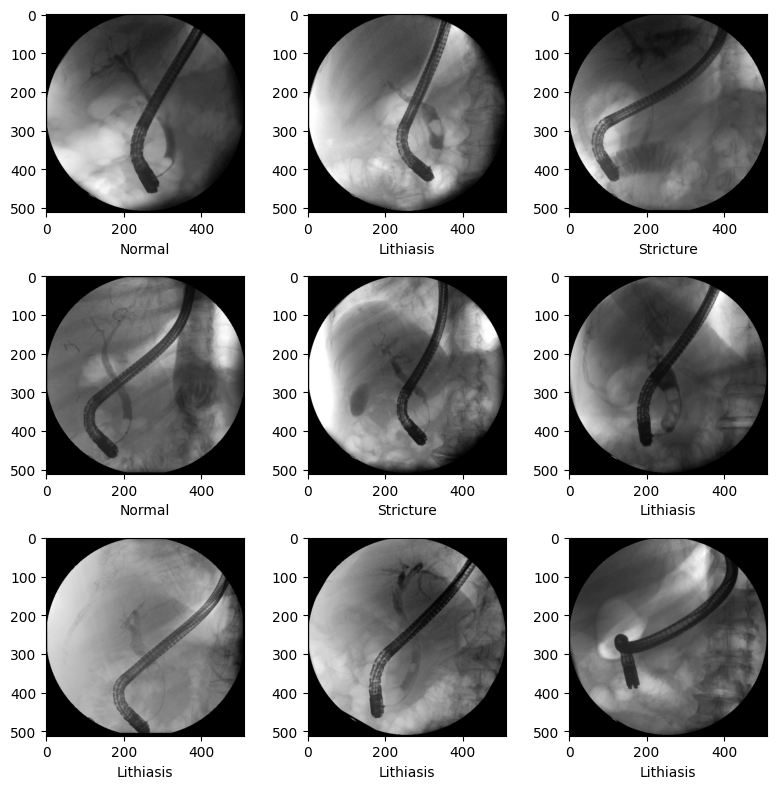

In [6]:
plt.subplots(3, 3, figsize=(8, 8))
for i, k in enumerate(np.random.randint(len(data['train']['images']), size=9)):
    im = Image.open(data['train']['images'][k])
    arr = np.array(im)
    plt.subplot(3, 3, i + 1)
    plt.xlabel(class_names[data['train']['labels'][k]])
    plt.imshow(arr, cmap='gray', vmin=0, vmax=255)
plt.tight_layout()
plt.show()

------ TRAIN CASES ------
cases: 1067
['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']
['0', '1', '2', '3']
[110 505 197 255]
1067


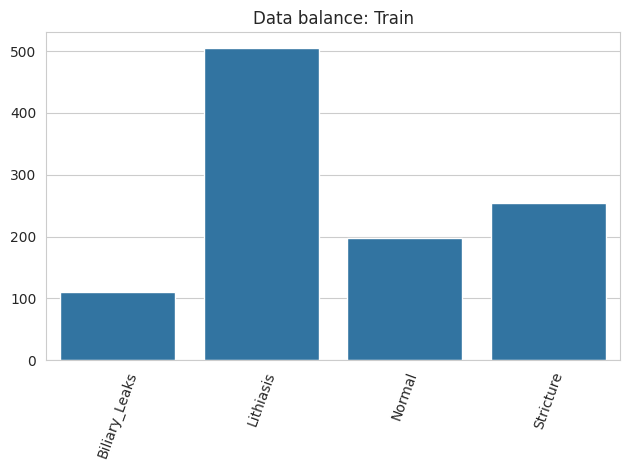

------ VALIDATION CASES ------
cases: 234
['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']
['0', '1', '2', '3']
[24 98 59 53]
234


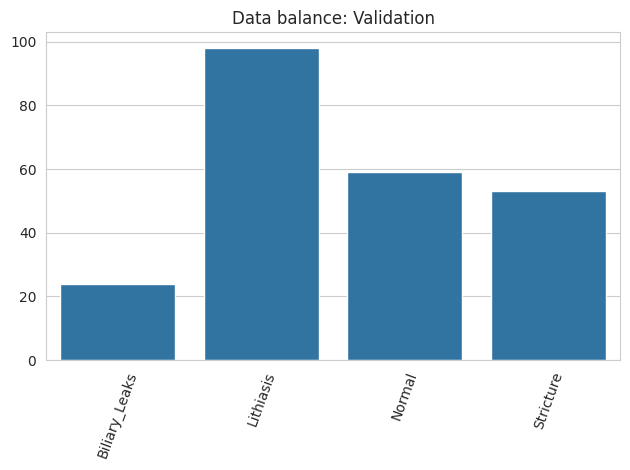

------ TEST CASES ------
cases: 267
['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']
['0', '1', '2', '3']
[ 17 123  43  84]
267


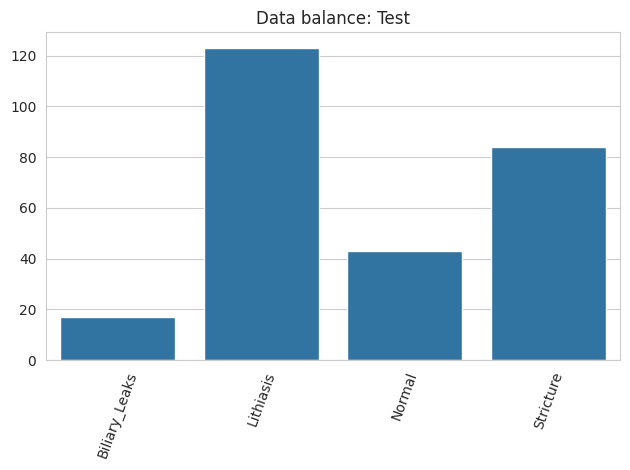

In [7]:
def visualize_holdout_balance(labels, class_names, header):
    sns.set_style('whitegrid')
    print("cases:", len(labels))
    x, y = np.unique(labels, return_counts=True)
    x_ext = [class_names[n] for n in x]
    print(x_ext)
    print([str(n) for n in x])
    print(y)
    print(np.sum(y))
    grafico = sns.barplot(x=x_ext, y=y)
    grafico.set_title(f'Data balance: {header}')
    plt.xticks(rotation=70)
    plt.tight_layout()
    plt.show()

print("------ TRAIN CASES ------")
visualize_holdout_balance(data['train']['labels'], class_names, 'Train')
print("------ VALIDATION CASES ------")
visualize_holdout_balance(data['val']['labels'], class_names, 'Validation')
print("------ TEST CASES ------")
visualize_holdout_balance(data['test']['labels'], class_names, 'Test')

In [8]:
class EnsureSingleChannel:
    def __call__(self, img):
        if img.shape[0] == 3:
            img = img.mean(dim=0, keepdim=True)
        return img

def repeat_if_needed(img):
    if img.shape[0] == 1:
        return img.repeat(3, 1, 1)
    return img

train_transforms = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    Resize((224, 224)),
    RandRotate(range_x=15, prob=0.5),
    RandFlip(spatial_axis=0, prob=0.5),
    RandFlip(spatial_axis=1, prob=0.5),
    RandZoom(min_zoom=0.9, max_zoom=1.1, prob=0.5),
    RandAdjustContrast(prob=0.5),
    RandGaussianNoise(prob=0.3, mean=0.0, std=0.01),
    NormalizeIntensity(),
    Lambda(repeat_if_needed),
    ToTensor()
])

val_transforms = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    Resize((224, 224)),
    NormalizeIntensity(),
    Lambda(repeat_if_needed),
    ToTensor()
])

act = Activations(softmax=True)
to_onehot = AsDiscrete(to_onehot=num_class)

In [9]:
class MedNISTDataset(Dataset):
    def __init__(self, image_files, labels, transforms):
        self.image_files = image_files
        self.labels = labels
        self.transforms = transforms

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, index):
        return self.transforms(self.image_files[index]), self.labels[index]

labels_train = data['train']['labels']
class_counts = np.bincount(labels_train)
class_weights = 1.0 / class_counts
sample_weights = [class_weights[l] for l in labels_train]
sampler = WeightedRandomSampler(
    weights=torch.tensor(sample_weights, dtype=torch.float),
    num_samples=len(sample_weights),
    replacement=True
)

train_ds = MedNISTDataset(data['train']['images'], data['train']['labels'], train_transforms)
val_ds = MedNISTDataset(data['val']['images'], data['val']['labels'], val_transforms)
test_ds = MedNISTDataset(data['test']['images'], data['test']['labels'], val_transforms)

train_loader = DataLoader(train_ds, batch_size=16, sampler=sampler, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=16, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=16, num_workers=0)

In [10]:
import os
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'max_split_size_mb:128'
torch.cuda.empty_cache()

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"A usar: {device}")

model = mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V1)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_class)

for param in model.features.parameters():
    param.requires_grad = False

model = model.to(device)
print("Modelo pronto — Fase 1: backbone congelado")
print(f"Parâmetros treináveis: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

A usar: cuda:0
Modelo pronto — Fase 1: backbone congelado
Parâmetros treináveis: 5,124


In [11]:
def train_model(train_dl, val_dl, model, loss_function, optimizer, epochs, name):
    early_stopping_patience = 10
    epochs_without_improvement = 0
    liveloss = PlotLosses(outputs=[MatplotlibPlot(figpath=f"{name}.png")])
    best_metric = -1
    best_metric_epoch = -1
    metric_values = list()

    f1_metric = MulticlassF1Score(num_classes=num_class, average='macro').to(device)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    for epoch in range(epochs):
        logs = {}
        model.train()
        running_loss = 0.0
        running_corrects = 0.0
        y_pred_train = torch.tensor([], dtype=torch.float32, device=device)
        y_train = torch.tensor([], dtype=torch.long, device=device)

        for inputs, labels in train_dl:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            loss = loss_function(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.detach() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            running_corrects += torch.sum(preds == labels.data)
            y_pred_train = torch.cat([y_pred_train, outputs], dim=0)
            y_train = torch.cat([y_train, labels], dim=0)

        epoch_loss = running_loss / len(train_dl.dataset)
        epoch_acc = running_corrects.float() / len(train_dl.dataset)
        pred_train_labels = y_pred_train.argmax(dim=1)
        f1_train_value = f1_metric(pred_train_labels, y_train)

        logs['loss'] = epoch_loss.item()
        logs['accuracy'] = epoch_acc.item()
        logs['F1'] = f1_train_value.item()

        model.eval()
        running_loss = 0.0
        running_corrects = 0.0
        y_pred = torch.tensor([], dtype=torch.float32, device=device)
        y = torch.tensor([], dtype=torch.long, device=device)

        with torch.no_grad():
            for val_images, val_labels in val_dl:
                val_images = val_images.to(device)
                val_labels = val_labels.to(device)
                outputs = model(val_images)
                loss = loss_function(outputs, val_labels)
                running_loss += loss.detach() * val_images.size(0)
                _, preds = torch.max(outputs, 1)
                running_corrects += torch.sum(preds == val_labels.data)
                y_pred = torch.cat([y_pred, outputs], dim=0)
                y = torch.cat([y, val_labels], dim=0)

            epoch_loss = running_loss / len(val_dl.dataset)
            epoch_acc = running_corrects.float() / len(val_dl.dataset)
            logs['val_loss'] = epoch_loss.item()
            logs['val_accuracy'] = epoch_acc.item()

            pred_labels = y_pred.argmax(dim=1)
            f1_score_value = f1_metric(pred_labels, y)
            logs['val_F1'] = f1_score_value.item()

            y_onehot = [to_onehot(i) for i in decollate_batch(y, detach=False)]
            y_pred_act = [act(i) for i in decollate_batch(y_pred)]
            auc_metric(y_pred_act, y_onehot)
            result = auc_metric.aggregate()
            auc_metric.reset()
            del y_pred_act, y_onehot
            metric_values.append(result)

            if f1_score_value > best_metric:
                best_metric = f1_score_value
                best_metric_epoch = epoch + 1
                best_train_f1 = f1_train_value.item()
                torch.save(model.state_dict(), name)
                print('saved new best metric model')
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1

            if epochs_without_improvement >= early_stopping_patience:
                print(
                    f"Early stopping at epoch {epoch + 1} \n"
                    f" Best Val F1: {best_metric:.4f} \n"
                    f" Best Train F1: {best_train_f1:.4f} \n"
                    f" current Val F1: {f1_score_value:.4f} \n"
                    f" current Train F1: {f1_train_value:.4f} \n"
                    f" Best epoch: {best_metric_epoch} \n"
                )
                break
            print(
                f"current epoch: {epoch + 1} current AUC: {result:.4f}"
                f" current F1 (train): {f1_train_value:.4f}"
                f" current F1 (val): {f1_score_value:.4f}"
                f" best F1: {best_metric:.4f}"
                f" at epoch: {best_metric_epoch}"
            )

        logs['val_AUC'] = result
        liveloss.update(logs)
        liveloss.send()
        scheduler.step()

    print(f"train completed, best_metric: {best_metric:.4f} at epoch: {best_metric_epoch}")

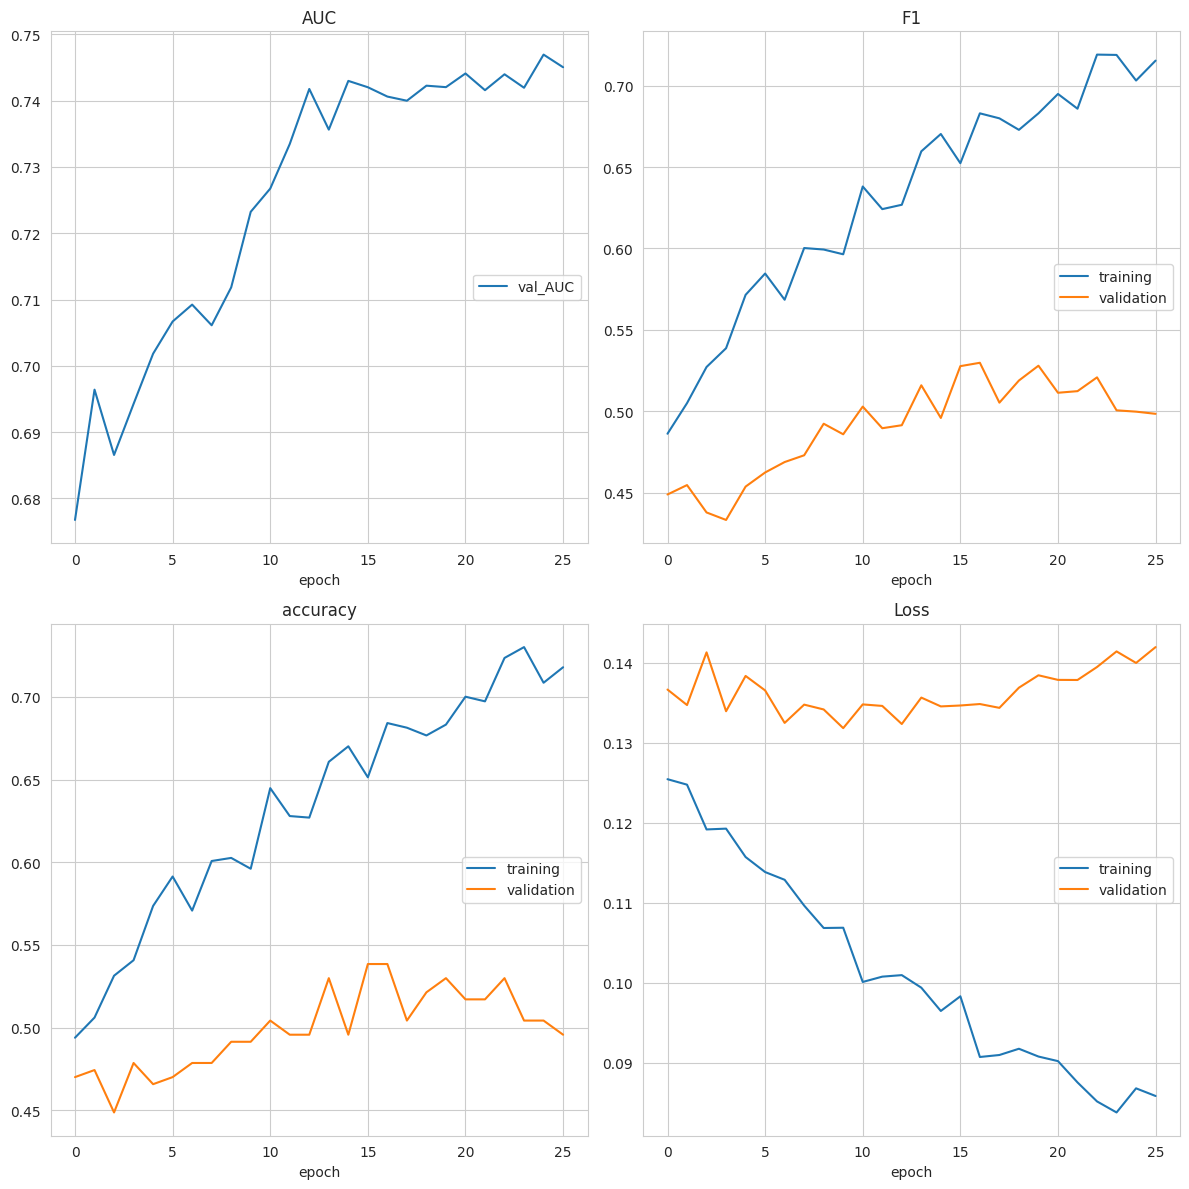

Early stopping at epoch 27 
 Best Val F1: 0.5298 
 Best Train F1: 0.6830 
 current Val F1: 0.5074 
 current Train F1: 0.6962 
 Best epoch: 17 

train completed, best_metric: 0.5298 at epoch: 17
Fase 2 concluída em 1317.1 segundos


In [13]:
from monai.losses import FocalLoss

model_name = 'mobilenet_v2_teresa.pth'
auc_metric = ROCAUCMetric()

print("="*50)
print("FASE 1: treinar só a cabeça (backbone congelado)")
print("="*50)

EPOCHS_FASE1 = 10
LR_FASE1 = 1e-3

loss_function = FocalLoss(to_onehot_y=True)
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), LR_FASE1)

starttime = time.perf_counter()
train_model(train_loader, val_loader, model, loss_function, optimizer, EPOCHS_FASE1, model_name)
endtime = time.perf_counter()
print(f"Fase 1 concluída em {endtime - starttime:.1f} segundos")

print("="*50)
print("FASE 2: fine-tuning completo (backbone descongelado)")
print("="*50)

for param in model.features.parameters():
    param.requires_grad = True

EPOCHS_FASE2 = 50
LR_FASE2 = 1e-5

optimizer = torch.optim.Adam(model.parameters(), LR_FASE2)

starttime = time.perf_counter()
train_model(train_loader, val_loader, model, loss_function, optimizer, EPOCHS_FASE2, model_name)
endtime = time.perf_counter()
print(f"Fase 2 concluída em {endtime - starttime:.1f} segundos")

F1 Score no teste: 0.4444
               precision    recall  f1-score   support

Biliary_Leaks     0.3529    0.3529    0.3529        17
    Lithiasis     0.5620    0.6260    0.5923       123
       Normal     0.2857    0.4186    0.3396        43
    Stricture     0.6600    0.3929    0.4925        84

     accuracy                         0.5019       267
    macro avg     0.4652    0.4476    0.4444       267
 weighted avg     0.5350    0.5019    0.5050       267



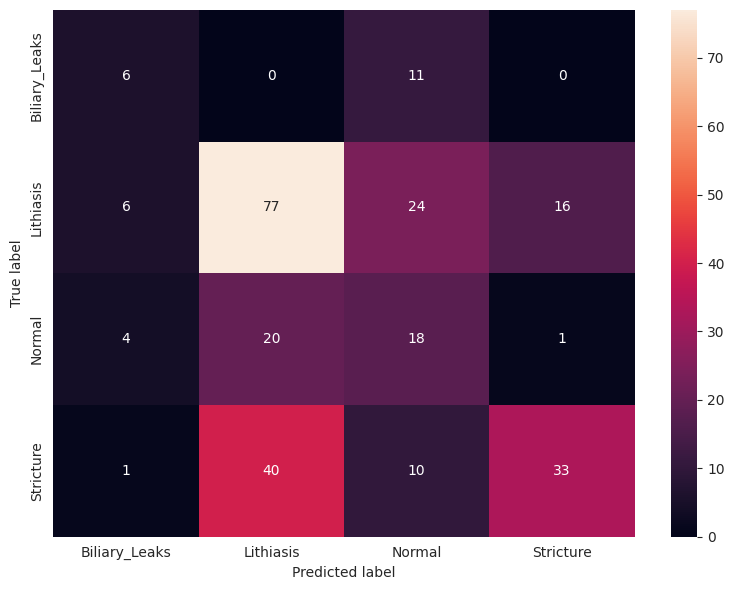

In [14]:
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import seaborn as sns

def evaluate_model(test_dl, model):
    model.load_state_dict(torch.load(model_name, map_location=device))
    model.eval()
    predictions = []
    actual_values = []
    
    with torch.no_grad():
        for inputs, labels in test_dl:
            inputs = inputs.to(device)
            yprev = model(inputs)
            yprev = yprev.detach().cpu().numpy()
            actual = labels.cpu().numpy()
            yprev = np.argmax(yprev, axis=1)
            actual = actual.reshape((len(actual), 1))
            yprev = yprev.reshape((len(yprev), 1))
            predictions.append(yprev)
            actual_values.append(actual)
    
    predictions, actual_values = np.vstack(predictions), np.vstack(actual_values)
    f1 = f1_score(actual_values, predictions, average='macro')
    print(f"F1 Score no teste: {f1:.4f}")
    print(classification_report(actual_values, predictions, target_names=class_names, digits=4))
    
    cm = confusion_matrix(actual_values, predictions)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, xticklabels=class_names, yticklabels=class_names, fmt='g')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()
    
    return actual_values, predictions

actual_values, predictions = evaluate_model(test_loader, model)

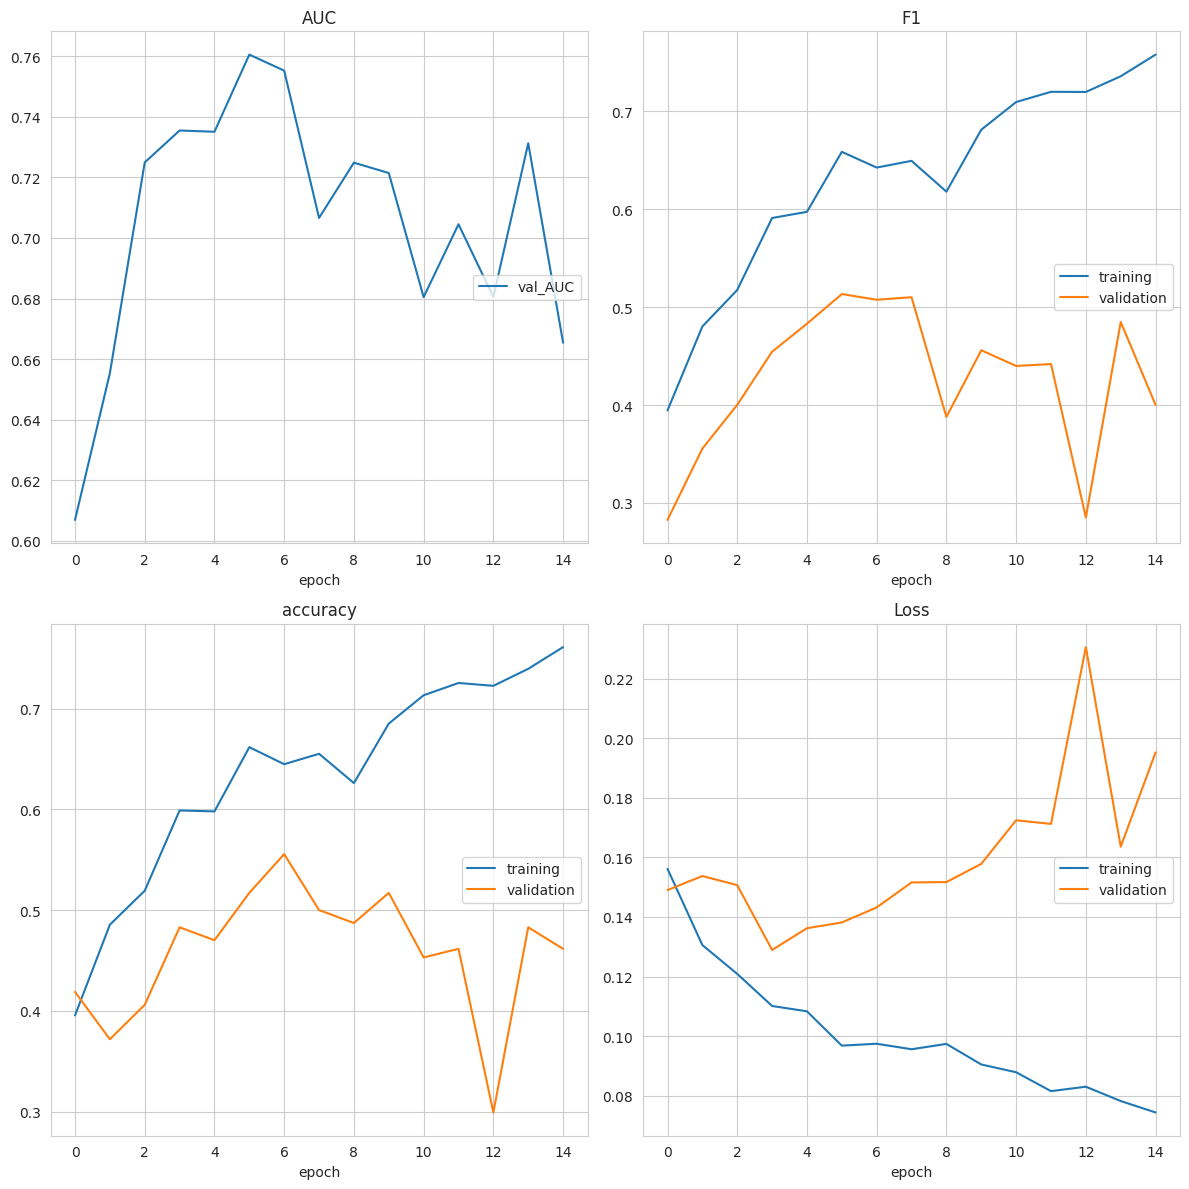

Early stopping at epoch 16 
 Best Val F1: 0.5133 
 Best Train F1: 0.6586 
 current Val F1: 0.4249 
 current Train F1: 0.7702 
 Best epoch: 6 

train completed, best_metric: 0.5133 at epoch: 6
Treino concluído em 769.6 segundos


In [15]:
# Reset do modelo
model = mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V1)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_class)

# Descongelar só as últimas 3 camadas do backbone
for param in model.features.parameters():
    param.requires_grad = False
for param in model.features[-3:].parameters():
    param.requires_grad = True

model = model.to(device)

model_name = 'mobilenet_v2_teresa_v2.pth'
auc_metric = ROCAUCMetric()

EPOCHS = 60
LR = 5e-4

loss_function = FocalLoss(to_onehot_y=True)
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), LR, weight_decay=1e-4)

starttime = time.perf_counter()
train_model(train_loader, val_loader, model, loss_function, optimizer, EPOCHS, model_name)
endtime = time.perf_counter()
print(f"Treino concluído em {endtime - starttime:.1f} segundos")

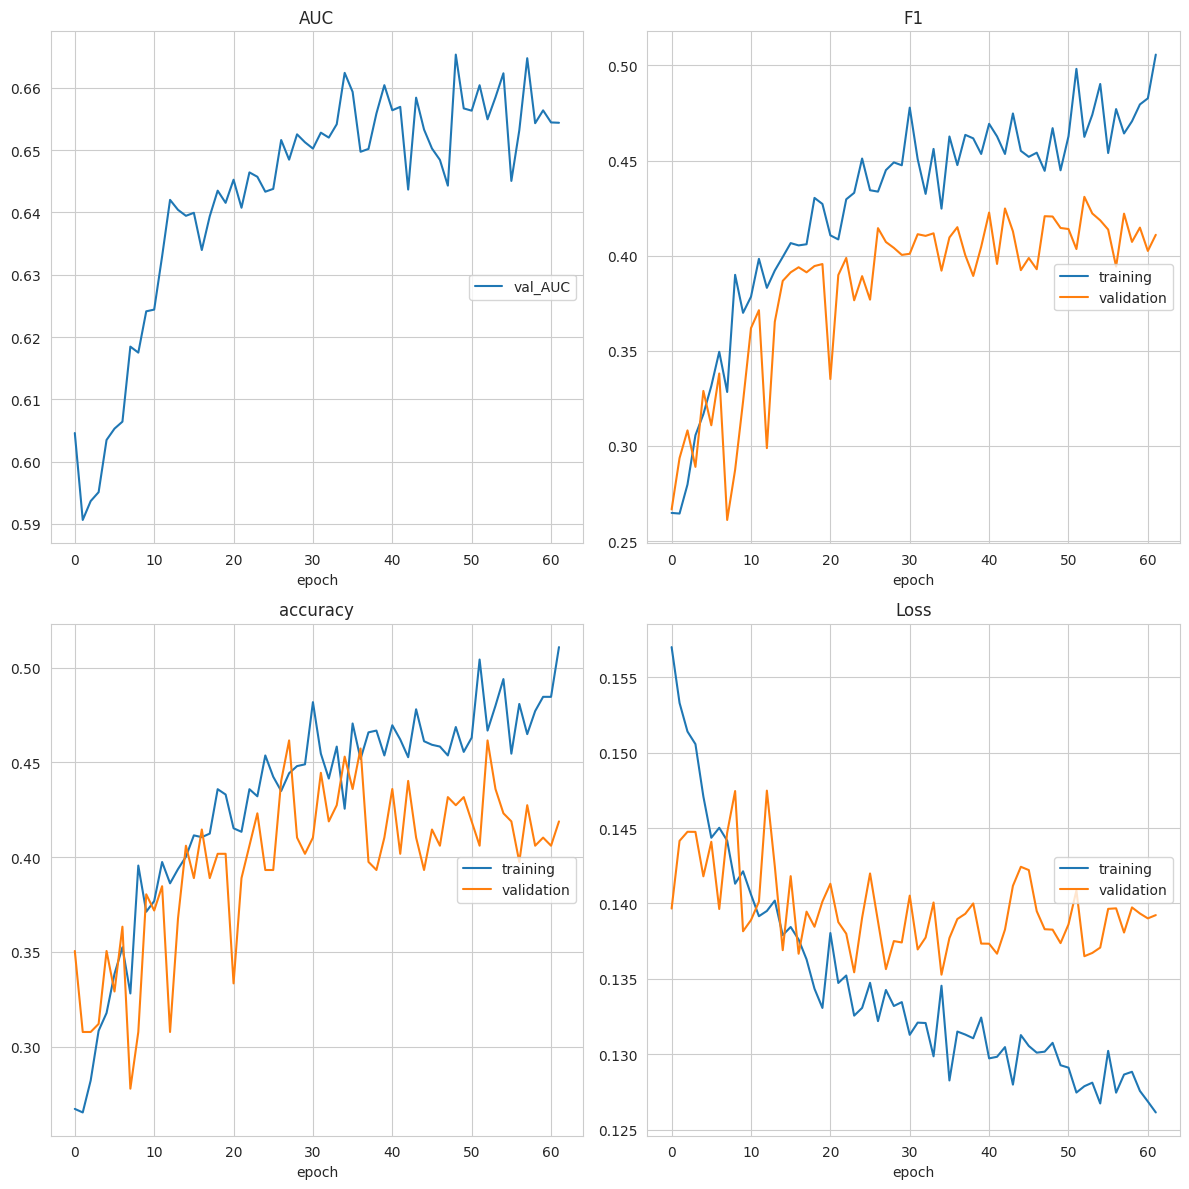

Early stopping at epoch 63 
 Best Val F1: 0.4309 
 Best Train F1: 0.4625 
 current Val F1: 0.4204 
 current Train F1: 0.4908 
 Best epoch: 53 

train completed, best_metric: 0.4309 at epoch: 53
Treino concluído em 2740.9 segundos


In [14]:
from monai.losses import FocalLoss
from monai.metrics import ROCAUCMetric
# Reset limpo
model = mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V1)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_class)

# Backbone completamente congelado
for param in model.features.parameters():
    param.requires_grad = False

model = model.to(device)

model_name = 'mobilenet_v2_teresa_v3.pth'
auc_metric = ROCAUCMetric()

EPOCHS = 80
LR = 1e-4

loss_function = FocalLoss(to_onehot_y=True)
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), 
    LR, 
    weight_decay=1e-3
)

starttime = time.perf_counter()
train_model(train_loader, val_loader, model, loss_function, optimizer, EPOCHS, model_name)
endtime = time.perf_counter()
print(f"Treino concluído em {endtime - starttime:.1f} segundos")